# Finite-Difference Option Pricing — A Learning Notebook

This notebook builds a European option pricer from first principles: it
derives the Black-Scholes PDE from a no-arbitrage hedging argument,
discretizes it step by step, shows *why* naive (explicit) time-stepping
blows up and how Crank-Nicolson fixes that, demonstrates the strike's payoff
kink corrupting convergence and how Rannacher smoothing repairs it, and
finally validates everything against the closed-form Black-Scholes price and
the project's tested library.

It's meant to be read top to bottom — each section motivates the next.

**Companion library:** [`../src/fd_option_pricing`](../src/fd_option_pricing)
(tested, documented, used for every "official" number in this notebook).
**Project README:** [`../README.md`](../README.md).
**Sibling project:** [Monte Carlo option pricing](../../monte-carlo-option-pricing/) —
the same pricing problem solved by simulation instead of a grid.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.linalg import solve_banded

from fd_option_pricing import bs_price, bs_greeks, crank_nicolson_price, fd_greeks

plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)

# Market / contract parameters used throughout this notebook
S0, K, r, sigma, T = 100.0, 105.0, 0.03, 0.25, 1.0
OPTION_TYPE = "call"

print(f"S0={S0}  K={K}  r={r}  sigma={sigma}  T={T}  option={OPTION_TYPE}")

S0=100.0  K=105.0  r=0.03  sigma=0.25  T=1.0  option=call


## 1. From a stochastic model to a deterministic PDE

Assume the underlying follows geometric Brownian motion under the real-world
measure:

$$
dS_t = \mu S_t\, dt + \sigma S_t\, dW_t
$$

Let $V(S, t)$ be the value of a derivative on $S$. By **Itô's lemma**:

$$
dV = \left(\frac{\partial V}{\partial t} + \mu S \frac{\partial V}{\partial S}
+ \frac12 \sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}\right) dt
+ \sigma S \frac{\partial V}{\partial S}\, dW
$$

**Hedge away the randomness.** Build a portfolio that is long one option and
short $\Delta = \partial V/\partial S$ shares of the underlying:

$$
\Pi = V - \frac{\partial V}{\partial S} S
$$

Then $d\Pi = dV - \frac{\partial V}{\partial S} dS$. Substituting both
expressions above, the $dW$ terms cancel exactly (that's the point of the
hedge — $\Delta$ was chosen precisely to make this happen), leaving a
purely deterministic change:

$$
d\Pi = \left(\frac{\partial V}{\partial t} + \frac12 \sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}\right) dt
$$

**No arbitrage.** A portfolio with no randomness must earn exactly the
risk-free rate, or an arbitrage would exist (borrow/lend the difference):

$$
d\Pi = r \Pi\, dt = r\left(V - S\frac{\partial V}{\partial S}\right) dt
$$

Setting the two expressions for $d\Pi$ equal and rearranging gives the
**Black-Scholes PDE**:

$$
\boxed{\frac{\partial V}{\partial t} + \frac12 \sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + r S \frac{\partial V}{\partial S} - rV = 0}
$$

Notice what's *missing*: $\mu$, the stock's real-world expected return,
dropped out entirely. Whatever investors believe about the stock's future
drift, it has no effect on the option's fair price — only the volatility
$\sigma$, the risk-free rate $r$, and the contract terms matter. This is the
PDE form of risk-neutral pricing.

## 2. Terminal and boundary conditions

The PDE alone has infinitely many solutions; a specific contract pins one
down via a **terminal condition** at maturity and **boundary conditions** at
the edges of the $S$ domain.

For a European call, $V(S, T) = \max(S - K, 0)$, and:

- As $S \to 0$: the option is worthless, $V(0, t) = 0$.
- As $S \to \infty$: exercise is a near-certainty, so the option behaves like
  a forward contract, $V(S, t) \approx S - K e^{-r(T-t)}$.

For a European put, $V(S, T) = \max(K - S, 0)$, and the boundary roles swap:
$V(0, t) = K e^{-r(T-t)}$ (certain exercise) and $V(S, t) \to 0$ as $S \to \infty$.

**Backward time.** The PDE is naturally posed backward: we *know* the value
at maturity $T$ and want the value today, $t=0$. Substituting
$\tau = T - t$ turns this into a forward march in $\tau$ — start from the
known payoff at $\tau=0$ and step forward to $\tau=T$, which is today's
price. Every solver in this notebook works in $\tau$.

## 3. From continuous to discrete: finite-difference approximations

A finite-difference method replaces derivatives with algebraic
approximations on a grid. For a small step $h$, Taylor expansion gives:

$$
f(x+h) = f(x) + h f'(x) + \frac{h^2}{2} f''(x) + \frac{h^3}{6} f'''(x) + \dots
$$

Subtracting the expansion at $x-h$ from the one at $x+h$ cancels the even
terms and isolates $f'(x)$ with $O(h^2)$ error — the **central difference**:

$$
f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}, \qquad
f''(x) \approx \frac{f(x+h) - 2f(x) + f(x-h)}{h^2}
$$

Both are second-order accurate: halving $h$ should quarter the error. Let's
check that on a function we know the derivative of exactly, $f(x)=\sin(x)$
at $x=1$, before trusting it on the PDE.

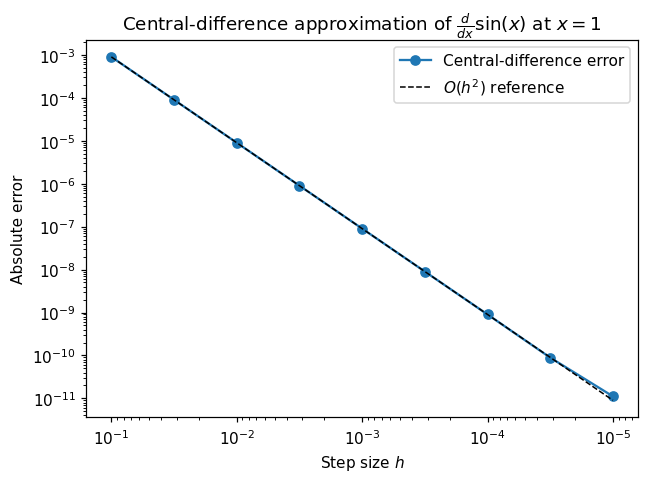

As h shrinks, the error tracks the O(h^2) line -- this is the same
building block we'll use for both d/dS and d2/dS2 in the PDE.


In [2]:
def central_diff_error(h):
    x = 1.0
    f_prime_approx = (np.sin(x + h) - np.sin(x - h)) / (2 * h)
    return abs(f_prime_approx - np.cos(x))  # cos(x) is the exact derivative of sin(x)

hs = np.logspace(-1, -5, 9)
errors = [central_diff_error(h) for h in hs]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(hs, errors, "o-", color="#1f77b4", label="Central-difference error")
ax.loglog(hs, errors[0] * (hs / hs[0]) ** 2, "k--", lw=1, label=r"$O(h^2)$ reference")
ax.set_xlabel("Step size $h$")
ax.set_ylabel("Absolute error")
ax.set_title(r"Central-difference approximation of $\frac{d}{dx}\sin(x)$ at $x=1$")
ax.legend()
ax.invert_xaxis()
fig.tight_layout()
plt.show()

print("As h shrinks, the error tracks the O(h^2) line -- this is the same")
print("building block we'll use for both d/dS and d2/dS2 in the PDE.")

## 4. Building the grid

Discretize $S$ into $M+1$ nodes $S_i = i \cdot \Delta S$ ($i=0,\dots,M$) and
$\tau$ into $N+1$ levels $\tau_n = n \cdot \Delta\tau$. $V_i^n$ denotes the
approximate option value at node $(S_i, \tau_n)$.

At $\tau_0=0$ every $V_i^0$ is known (the payoff). The scheme's job is to
propagate that row forward, one $\tau$-level at a time, until $\tau_N = T$.

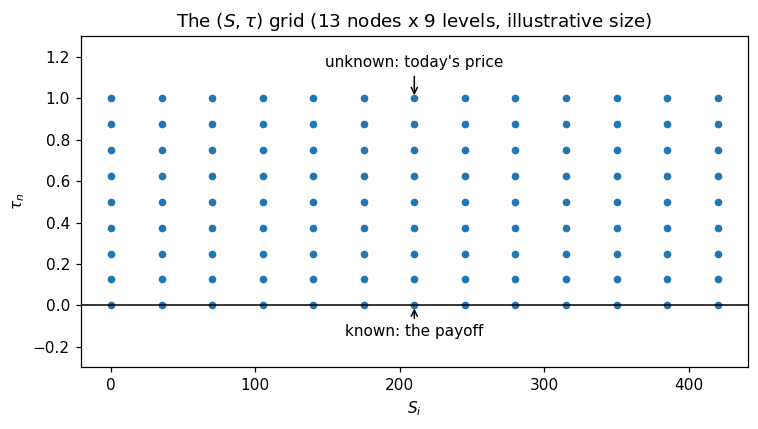

In [3]:
M_demo, N_demo = 12, 8
S_max_demo = 4 * max(S0, K)
dS_demo = S_max_demo / M_demo
dtau_demo = T / N_demo

S_nodes = np.arange(M_demo + 1) * dS_demo
tau_levels = np.arange(N_demo + 1) * dtau_demo

fig, ax = plt.subplots(figsize=(7, 4))
for tau in tau_levels:
    ax.plot(S_nodes, np.full_like(S_nodes, tau), "o", color="#1f77b4", ms=4)
ax.axhline(0, color="black", lw=1)
ax.set_xlabel("$S_i$")
ax.set_ylabel(r"$\tau_n$")
ax.set_title(f"The $(S, \\tau)$ grid ({M_demo+1} nodes x {N_demo+1} levels, illustrative size)")
ax.annotate("known: the payoff", xy=(S_nodes[6], 0), xytext=(S_nodes[6], -0.15),
            ha="center", arrowprops=dict(arrowstyle="->"))
ax.annotate("unknown: today's price", xy=(S_nodes[6], tau_levels[-1]), xytext=(S_nodes[6], tau_levels[-1] + 0.15),
            ha="center", arrowprops=dict(arrowstyle="->"))
ax.set_ylim(-0.3, tau_levels[-1] + 0.3)
fig.tight_layout()
plt.show()

## 5. The theta-method: explicit, implicit, and why explicit blows up

Substituting the central differences from Section 3 into the PDE turns it
into a system of ODEs in $\tau$, one per interior node:

$$
\frac{dV_i}{d\tau} = a_i V_{i-1} + b_i V_i + c_i V_{i+1} \equiv f(V)_i,
\qquad
\begin{aligned}
a_i &= \tfrac12\sigma^2 i^2 - \tfrac12 r i \\
b_i &= -\sigma^2 i^2 - r \\
c_i &= \tfrac12\sigma^2 i^2 + \tfrac12 r i
\end{aligned}
$$

(these fall out directly from substituting $S_i = i\,\Delta S$ into the PDE's
$S$ and $S^2$ coefficients). The **theta-method** discretizes the $\tau$
derivative as a weighted blend of the old and new time levels:

$$
V_i^{n+1} - V_i^n = \theta\, \Delta\tau \cdot f(V^{n+1})_i + (1-\theta)\, \Delta\tau \cdot f(V^n)_i
$$

| $\theta$ | Scheme | Accuracy | Stability |
|---|---|---|---|
| 0 | Explicit | $O(\Delta\tau)$ | conditional — needs $\Delta\tau = O(\Delta S^2)$ |
| 1 | Fully implicit | $O(\Delta\tau)$ | unconditional |
| 0.5 | Crank-Nicolson | $O(\Delta\tau^2)$ | unconditional |

$\theta=0$ (explicit) needs no linear solve — $V_i^{n+1}$ reads directly off
known values — which is tempting, but it is only stable if $\Delta\tau$ is
tiny relative to $\Delta S^2$. Push $\Delta\tau$ past that threshold and the
solution doesn't just get inaccurate, it **diverges**. Let's see it happen.

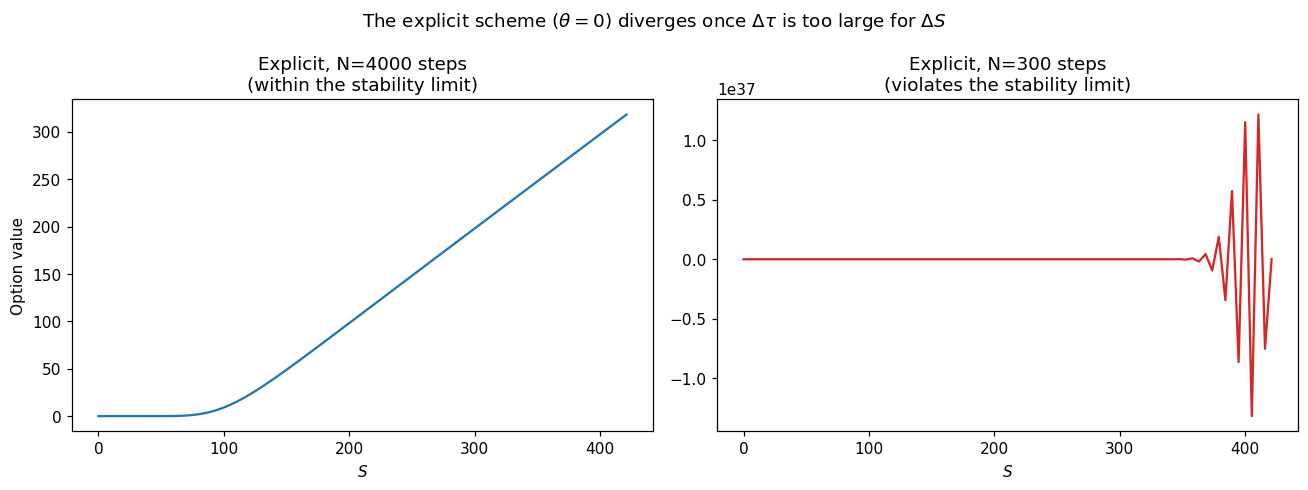

Same S-grid (M=80) both times -- only N (and hence dtau) changed.
max|V| stable run:   318.10
max|V| unstable run: 1.32e+37  <- note the scale


In [4]:
def solve_theta_scheme(S0, K, r, sigma, T, option_type="call", S_max=None,
                       M=200, N=200, theta=0.5, rannacher_steps=0, record_history=False):
    '''A from-scratch theta-scheme PDE solver, written here to make the
    mechanics visible. theta=0 is explicit, 0.5 is Crank-Nicolson, 1 is fully
    implicit. Every *priced* result in this notebook instead calls the
    tested library (fd_option_pricing.crank_nicolson_price) -- this function
    exists only to illustrate the scheme and to record full time histories
    for the plots below, which the library (reasonably) doesn't expose.
    '''
    S_max = S_max or 4.0 * max(S0, K)
    n0 = max(1, round(S0 / (S_max / M)))
    dS = S0 / n0
    M = round(S_max / dS)
    dtau = T / N
    i = np.arange(0, M + 1)
    S = i * dS

    V = np.maximum(S - K, 0.0) if option_type == "call" else np.maximum(K - S, 0.0)
    a = 0.5 * sigma**2 * i**2 - 0.5 * r * i
    b = -sigma**2 * i**2 - r
    c = 0.5 * sigma**2 * i**2 + 0.5 * r * i
    interior = slice(1, M)

    def boundary(tau):
        if option_type == "call":
            return 0.0, S_max - K * np.exp(-r * tau)
        return K * np.exp(-r * tau), 0.0

    history = [V.copy()] if record_history else None

    for n in range(N):
        theta_used = 1.0 if n < rannacher_steps else theta
        A, B, G = theta_used * dtau * a, theta_used * dtau * b, theta_used * dtau * c
        Ae, Be, Ge = (1 - theta_used) * dtau * a, (1 - theta_used) * dtau * b, (1 - theta_used) * dtau * c

        V0n, VMn = boundary((n + 1) * dtau)
        d = Ae[interior] * V[: M - 1] + (1 + Be[interior]) * V[interior] + Ge[interior] * V[2 : M + 1]
        d[0] += A[1] * V0n
        d[-1] += G[M - 1] * VMn

        if theta_used == 0.0:
            V_interior = d  # explicit: no linear system, just read off known values
        else:
            n_interior = M - 1
            ab = np.zeros((3, n_interior))
            ab[0, 1:] = -G[1 : M - 1]
            ab[1, :] = 1.0 - B[interior]
            ab[2, :-1] = -A[2:M]
            V_interior = solve_banded((1, 1), ab, d)

        V = np.empty(M + 1)
        V[0], V[-1] = V0n, VMn
        V[interior] = V_interior
        if record_history:
            history.append(V.copy())

    return (S, np.array(history)) if record_history else (S, V)


# A fixed, fairly fine S-grid, with two very different numbers of time steps.
M_stab = 80
N_stable = 4000     # small dtau -> satisfies the explicit stability limit
N_unstable = 300    # larger dtau -> violates it

S_a, V_stable = solve_theta_scheme(S0, K, r, sigma, T, OPTION_TYPE, M=M_stab, N=N_stable, theta=0.0)
S_b, V_unstable = solve_theta_scheme(S0, K, r, sigma, T, OPTION_TYPE, M=M_stab, N=N_unstable, theta=0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(S_a, V_stable, color="#1f77b4")
axes[0].set_title(f"Explicit, N={N_stable} steps\n(within the stability limit)")
axes[0].set_xlabel("$S$"); axes[0].set_ylabel("Option value")

axes[1].plot(S_b, V_unstable, color="#d62728")
axes[1].set_title(f"Explicit, N={N_unstable} steps\n(violates the stability limit)")
axes[1].set_xlabel("$S$")

fig.suptitle("The explicit scheme ($\\theta=0$) diverges once $\\Delta\\tau$ is too large for $\\Delta S$")
fig.tight_layout()
plt.show()

print(f"Same S-grid (M={M_stab}) both times -- only N (and hence dtau) changed.")
print(f"max|V| stable run:   {np.max(np.abs(V_stable)):.2f}")
print(f"max|V| unstable run: {np.max(np.abs(V_unstable)):.2e}  <- note the scale")

Crank-Nicolson and fully implicit ($\theta \ge 0.5$) don't have this failure
mode — they're unconditionally stable for *any* $\Delta\tau$, which is why
the library only ever uses $\theta \in \{0.5, 1\}$ and never $\theta=0$.

## 6. Assembling the linear system

For $\theta > 0$, the unknowns at the new time level are coupled: $V_i^{n+1}$
depends on its neighbors $V_{i-1}^{n+1}$ and $V_{i+1}^{n+1}$, which are
themselves unknown. Moving the unknowns to one side turns each time step
into a **tridiagonal linear system**:

$$
-\alpha_i V_{i-1}^{n+1} + (1-\beta_i) V_i^{n+1} - \gamma_i V_{i+1}^{n+1}
= \alpha_i V_{i-1}^{n} + (1+\beta_i) V_i^{n} + \gamma_i V_{i+1}^{n}
$$

with $\alpha_i=\theta\Delta\tau\, a_i$, $\beta_i=\theta\Delta\tau\, b_i$,
$\gamma_i=\theta\Delta\tau\, c_i$. Only three diagonals are non-zero, so this
solves in $O(M)$ time via the Thomas algorithm
(`scipy.linalg.solve_banded`) instead of the $O(M^3)$ a dense solve would
cost. Here's what that matrix actually looks like for a small, illustrative
grid:

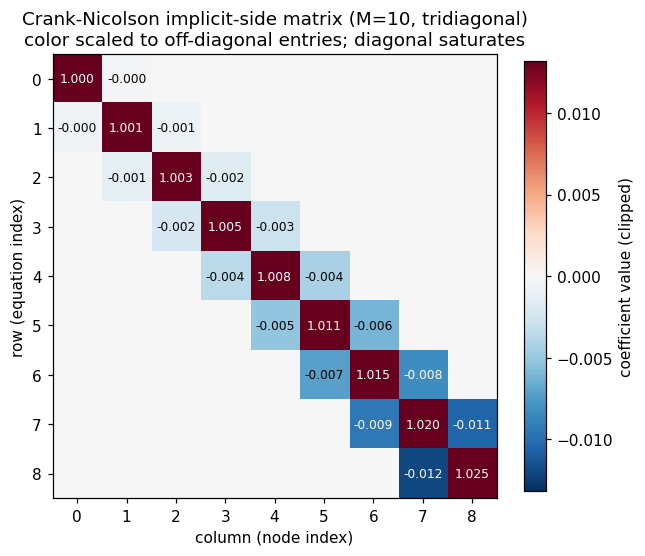

In [5]:
M_tiny = 10
i_tiny = np.arange(0, M_tiny + 1)
dtau_tiny = 0.01
a_t = 0.5 * sigma**2 * i_tiny**2 - 0.5 * r * i_tiny
b_t = -sigma**2 * i_tiny**2 - r
c_t = 0.5 * sigma**2 * i_tiny**2 + 0.5 * r * i_tiny
theta_tiny = 0.5

A_mat = np.zeros((M_tiny - 1, M_tiny - 1))
for row, i in enumerate(range(1, M_tiny)):
    alpha, beta, gamma = theta_tiny * dtau_tiny * a_t[i], theta_tiny * dtau_tiny * b_t[i], theta_tiny * dtau_tiny * c_t[i]
    A_mat[row, row] = 1 - beta
    if row > 0:
        A_mat[row, row - 1] = -alpha
    if row < M_tiny - 2:
        A_mat[row, row + 1] = -gamma

off_diag = A_mat - np.diag(np.diag(A_mat))
clip = np.abs(off_diag).max() * 1.1  # scale color to the off-diagonals; the
                                      # diagonal (~1.03) saturates on purpose

fig, ax = plt.subplots(figsize=(6, 5.5))
im = ax.imshow(A_mat, cmap="RdBu_r", vmin=-clip, vmax=clip)
for row in range(A_mat.shape[0]):
    for col in range(A_mat.shape[1]):
        val = A_mat[row, col]
        if val != 0:
            ax.text(col, row, f"{val:.3f}", ha="center", va="center", fontsize=8,
                     color="white" if abs(val) > clip * 0.6 else "black")
ax.set_title(f"Crank-Nicolson implicit-side matrix (M={M_tiny}, tridiagonal)\ncolor scaled to off-diagonal entries; diagonal saturates")
ax.set_xlabel("column (node index)")
ax.set_ylabel("row (equation index)")
fig.colorbar(im, ax=ax, shrink=0.8, label="coefficient value (clipped)")
fig.tight_layout()
plt.show()

## 7. The strike's kink, and Rannacher smoothing

The terminal payoff $\max(S-K, 0)$ has a **discontinuous first derivative**
at $S=K$. Crank-Nicolson's second-order accuracy assumes a smooth solution;
a kink injects high-frequency error that Crank-Nicolson doesn't damp (it's
only *marginally* stable at the highest frequencies), producing small
spurious oscillations that pollute the convergence rate for a few steps
after $\tau=0$.

**Rannacher smoothing** is the standard fix: run the first couple of steps
fully implicit ($\theta=1$, which damps high frequencies aggressively) before
switching to Crank-Nicolson. `crank_nicolson_price` does this by default
(`rannacher_steps=2`).

The clearest way to see why this matters isn't price — price is an
*integral* of the payoff against a smoothing kernel, so it's naturally
forgiving of a local kink. **Gamma** is a *second derivative*, which
amplifies high-frequency error far more. And the effect is starkest with
just a handful of time steps (a large $\Delta\tau$ relative to $\Delta S^2$),
since that's the single CN step right after the kink where the spurious
oscillation is largest, before it's had time to damp away. Using the library
directly, with a fine $S$-grid but only 2 time steps for the whole year:

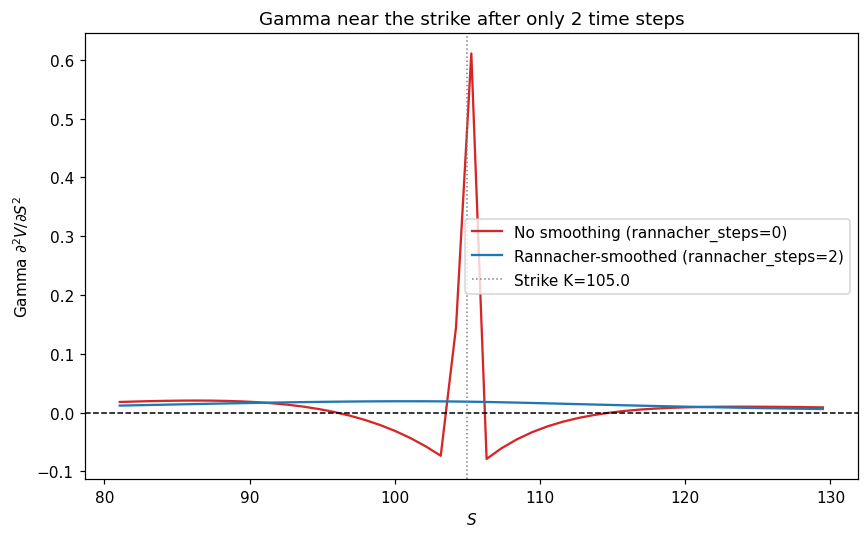

No smoothing:  gamma ranges -0.079 to 0.611
Smoothed:      gamma ranges 0.006 to 0.019

Gamma of a vanilla call/put must be >= 0 everywhere (convexity of the payoff).
The unsmoothed curve dipping negative is a real, physically impossible artifact
of the kink -- not just numerical noise you can shrug off.


In [6]:
M_gamma, N_gamma = 400, 2

fd_plain = crank_nicolson_price(S0, K, r, sigma, T, OPTION_TYPE, M=M_gamma, N=N_gamma, rannacher_steps=0)
fd_smooth = crank_nicolson_price(S0, K, r, sigma, T, OPTION_TYPE, M=M_gamma, N=N_gamma, rannacher_steps=2)

def gamma_profile(fd_result):
    S, V = fd_result.S_grid, fd_result.V_grid
    dS = S[1] - S[0]
    gamma = (V[2:] - 2 * V[1:-1] + V[:-2]) / dS**2
    return S[1:-1], gamma

S_g, gamma_plain = gamma_profile(fd_plain)
_, gamma_smooth = gamma_profile(fd_smooth)
window = (S_g > 80) & (S_g < 130)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(S_g[window], gamma_plain[window], color="#d62728", label="No smoothing (rannacher_steps=0)")
ax.plot(S_g[window], gamma_smooth[window], color="#1f77b4", label="Rannacher-smoothed (rannacher_steps=2)")
ax.axhline(0, color="black", lw=1, linestyle="--")
ax.axvline(K, color="gray", lw=1, linestyle=":", label=f"Strike K={K}")
ax.set_xlabel("$S$")
ax.set_ylabel(r"Gamma $\partial^2 V/\partial S^2$")
ax.set_title(f"Gamma near the strike after only {N_gamma} time steps")
ax.legend()
fig.tight_layout()
plt.show()

print(f"No smoothing:  gamma ranges {gamma_plain[window].min():.3f} to {gamma_plain[window].max():.3f}")
print(f"Smoothed:      gamma ranges {gamma_smooth[window].min():.3f} to {gamma_smooth[window].max():.3f}")
print("\nGamma of a vanilla call/put must be >= 0 everywhere (convexity of the payoff).")
print("The unsmoothed curve dipping negative is a real, physically impossible artifact")
print("of the kink -- not just numerical noise you can shrug off.")

With many time steps (the regime used for actual pricing from Section 8
onward), this oscillation has more steps to damp out even without Rannacher
smoothing, so its effect on the *final* price is present but far subtler
than this dramatic few-step gamma picture — which is exactly why textbooks
motivate Rannacher smoothing via Greek stability rather than raw price
convergence.

## 8. Pricing with the library, and visualizing the full solution

From here on, every number comes from the tested library
(`fd_option_pricing.crank_nicolson_price`), not the illustrative solver
above. The grid is chosen so `S0` lands exactly on a node, so the price and
the grid-based Greeks (delta, gamma, theta) need no interpolation.

In [7]:
fd = crank_nicolson_price(S0, K, r, sigma, T, OPTION_TYPE, M=200, N=200)
bs = bs_price(S0, K, r, sigma, T, OPTION_TYPE)

print(f"Black-Scholes price:  {bs:.4f}")
print(f"Crank-Nicolson price: {fd.price:.4f}  (abs. error {abs(fd.price - bs):.5f})")

Black-Scholes price:  9.1218
Crank-Nicolson price: 9.1213  (abs. error 0.00055)


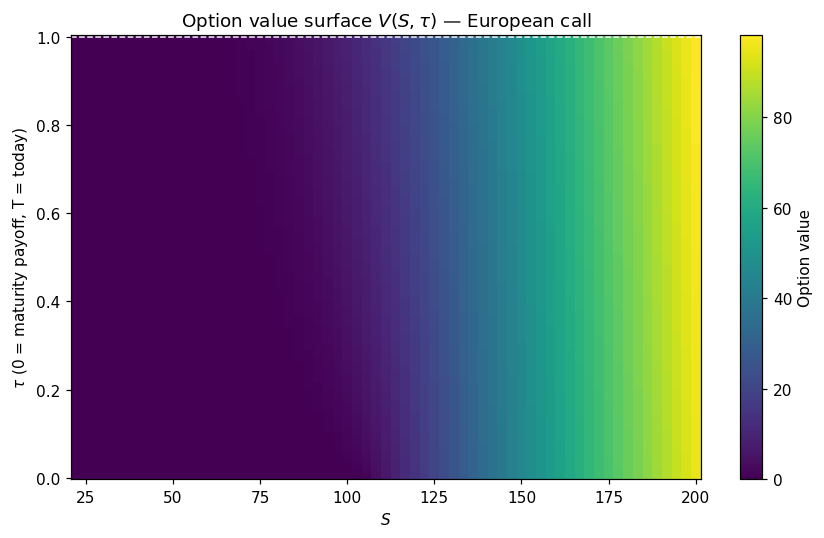

Bottom row (tau=0): the kinked terminal payoff.
Top row (tau=T):    today's smooth price curve -- exactly fd.V_grid from the library.


In [8]:
# Full (S, tau) solution surface, via the illustrative recorder from Section 5/6,
# using the same theta=0.5 + Rannacher(2) scheme the library uses.
S_surf, V_history = solve_theta_scheme(S0, K, r, sigma, T, OPTION_TYPE, M=150, N=150,
                                        theta=0.5, rannacher_steps=2, record_history=True)
tau_surf = np.linspace(0, T, V_history.shape[0])
mask = (S_surf >= 0.2 * S0) & (S_surf <= 2.0 * S0)

fig, ax = plt.subplots(figsize=(8, 5))
mesh = ax.pcolormesh(S_surf[mask], tau_surf, V_history[:, mask], shading="auto", cmap="viridis")
ax.set_xlabel("$S$")
ax.set_ylabel(r"$\tau$ (0 = maturity payoff, T = today)")
ax.set_title(f"Option value surface $V(S, \\tau)$ — European {OPTION_TYPE}")
ax.axhline(T, color="white", lw=1, linestyle="--")
fig.colorbar(mesh, ax=ax, label="Option value")
fig.tight_layout()
plt.show()

print("Bottom row (tau=0): the kinked terminal payoff.")
print("Top row (tau=T):    today's smooth price curve -- exactly fd.V_grid from the library.")

## 9. Verifying against Black-Scholes

Price accuracy is only half the story for a usable pricer — the Greeks need
to hold up too. Delta, gamma, and theta come straight off the grid; vega and
rho come from bumping $\sigma$/$r$ and re-solving (`fd_greeks`), which is
exact up to discretization error since the solver has no randomness to
average out, unlike Monte Carlo.

In [9]:
bs_g = bs_greeks(S0, K, r, sigma, T, OPTION_TYPE)
fd_g = fd_greeks(S0, K, r, sigma, T, OPTION_TYPE, M=200, N=200)

greeks_df = pd.DataFrame({"Black-Scholes": bs_g, "Crank-Nicolson": fd_g})
greeks_df["abs. diff"] = (greeks_df["Black-Scholes"] - greeks_df["Crank-Nicolson"]).abs()
display(greeks_df)

,Black-Scholes,Crank-Nicolson,abs. diff
delta,0.519875,0.519747,0.000128
gamma,0.015938,0.015940,0.000002
vega,39.844711,39.846618,0.001907
theta,-6.266559,-6.272990,0.006430
rho,42.865680,42.862127,0.003553


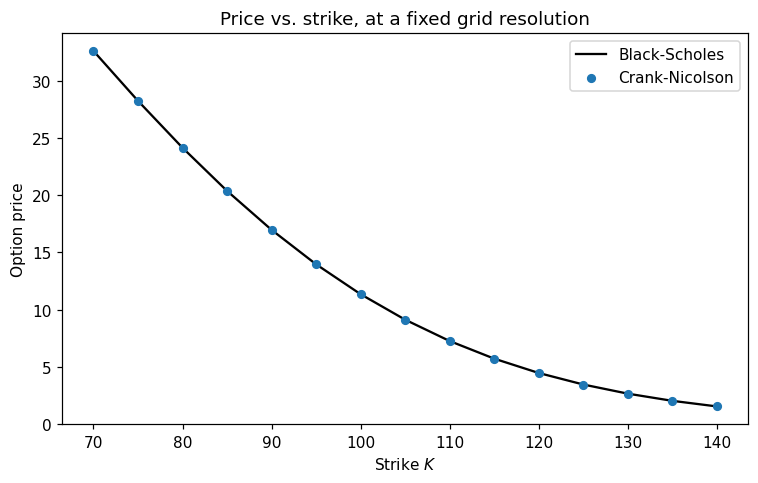

In [10]:
strikes = np.linspace(70, 140, 15)
bs_by_strike = [bs_price(S0, k, r, sigma, T, OPTION_TYPE) for k in strikes]
fd_by_strike = [crank_nicolson_price(S0, k, r, sigma, T, OPTION_TYPE, M=200, N=200).price for k in strikes]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(strikes, bs_by_strike, color="black", label="Black-Scholes")
ax.scatter(strikes, fd_by_strike, color="#1f77b4", s=25, zorder=3, label="Crank-Nicolson")
ax.set_xlabel("Strike $K$")
ax.set_ylabel("Option price")
ax.set_title("Price vs. strike, at a fixed grid resolution")
ax.legend()
fig.tight_layout()
plt.show()

## 10. Summary

- The Black-Scholes PDE falls out of a delta-hedging argument plus
  no-arbitrage — no need to assume investors are risk-neutral, it's a
  consequence of the hedge, and the stock's real-world drift $\mu$ never
  appears.
- Central differences turn the PDE into a tridiagonal linear system per time
  step; which $\theta$ you pick trades off accuracy against stability, and
  explicit ($\theta=0$) is a trap — it looks simpler but silently requires
  $\Delta\tau = O(\Delta S^2)$ or it diverges.
- Crank-Nicolson ($\theta=0.5$) is unconditionally stable and second-order,
  but the kinked payoff still needs help (Rannacher smoothing) to realize
  that order in practice.
- A converged PDE solve gives you the price *and* delta/gamma/theta for
  free off a single grid — the qualitative advantage over Monte Carlo for
  low-dimensional problems, at the cost of the grid growing expensive fast
  as dimensions (extra state variables) are added.

### Suggested exercises

- Change `theta_tiny` in Section 6 and re-plot the matrix for `theta=1.0` —
  how does the implicit-side matrix change?
- In Section 5, find (by trial) roughly how large `N` needs to be, for a
  fixed `M_stab`, before the explicit scheme stops diverging — does it match
  an $O(\Delta S^2)$ scaling if you also change `M_stab`?
- Try `rannacher_steps=0, 1, 2, 4` in Section 7 and see how the fitted order
  changes.
- Price a put instead of a call throughout (`OPTION_TYPE = "put"`) and check
  put-call parity holds on the grid.
- Extend `crank_nicolson_price` to American exercise by adding a
  early-exercise projection (`V = np.maximum(V, payoff)`) after each solve —
  compare the resulting price to the European one.